In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
tpg_data = '/content/drive/MyDrive/Colab Notebooks/HEConomist/Article_15/collisions-tpg-avec-tiers.csv'
df_tpg = pd.read_csv(tpg_data, sep=';')

In [2]:
print(df_tpg.dtypes)

Evt NumEr                               object
Jour                                    object
Heure                                   object
Cat                                     object
Ss Cat                                  object
Indicateur de Sévérité                 float64
Ligne                                   object
Sens                                    object
Arrêt                                   object
Ligne Type Hist.                        object
Ligne Catégorie Hist.                   object
Latitude                               float64
Longitude                              float64
Niv. Blessure (Humain)                 float64
Niv. Conséquences (Opérationnel)       float64
Niv. de Retentissement (Médiatique)    float64
Niveau Exploitation (Matériel)         float64
coordonnees_geo                         object
dtype: object


In [3]:
print(df_tpg.describe())

       Indicateur de Sévérité     Latitude    Longitude  \
count             9870.000000  9870.000000  9870.000000   
mean                 1.004174    46.204671     6.139838   
std                  0.238108     0.022878     0.037525   
min                  0.800000    46.098869     5.931602   
25%                  0.900000    46.193670     6.123553   
50%                  0.900000    46.203073     6.141788   
75%                  1.100000    46.212124     6.155798   
max                  3.000000    46.493847     6.306122   

       Niv. Blessure (Humain)  Niv. Conséquences (Opérationnel)  \
count             9870.000000                       9870.000000   
mean                 0.089159                          0.524113   
std                  0.317928                          0.585246   
min                  0.000000                          0.000000   
25%                  0.000000                          0.000000   
50%                  0.000000                          0.500000   

In [4]:
TPG_Details = ['Jour', 'Heure', 'Cat', 'Indicateur de Sévérité', 'Ligne', 'Arrêt', 'Niv. Blessure (Humain)', 'Niveau Exploitation (Matériel)']
TPG_Details = df_tpg[TPG_Details]
print(TPG_Details)

            Jour     Heure       Cat  Indicateur de Sévérité     Ligne  \
0     2019-03-14  20:35:00  Accident                     0.9        31   
1     2023-10-16  18:51:00  Accident                     0.9         F   
2     2025-06-12  14:00:00  Accident                     0.9        60   
3     2022-09-09  16:02:00  Accident                     0.8         F   
4     2021-02-01  15:43:00  Accident                     1.1         F   
...          ...       ...       ...                     ...       ...   
9865  2023-06-27  15:39:00  Accident                     1.1        63   
9866  2018-08-08  15:31:00  Accident                     0.8         M   
9867  2016-12-06  06:53:00  Accident                     0.9        DN   
9868  2019-05-27  15:31:00  Accident                     0.9         N   
9869  2025-04-16  07:52:00  Accident                     0.8  NotFound   

                          Arrêt  Niv. Blessure (Humain)  \
0               P+R Sous-Moulin                     

In [5]:
TPG_Accidents = TPG_Details[TPG_Details['Cat'] == 'Accident']

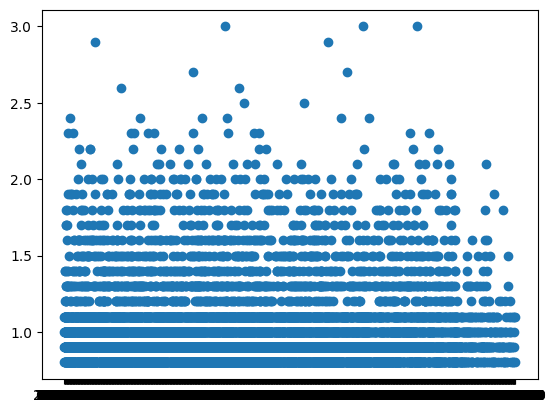

In [6]:
plt.scatter(TPG_Accidents['Heure'], TPG_Accidents['Indicateur de Sévérité'])

EDA

In [7]:
# Work on a copy to avoid SettingWithCopy warnings
TPG_Accidents = TPG_Details[TPG_Details['Cat'] == 'Accident'].copy()

# Convert Heure to datetime (time-like)
TPG_Accidents['Heure_dt'] = pd.to_datetime(TPG_Accidents['Heure'], format='%H:%M:%S', errors='coerce')

# Extract hour only
TPG_Accidents['Hour'] = TPG_Accidents['Heure_dt'].dt.hour


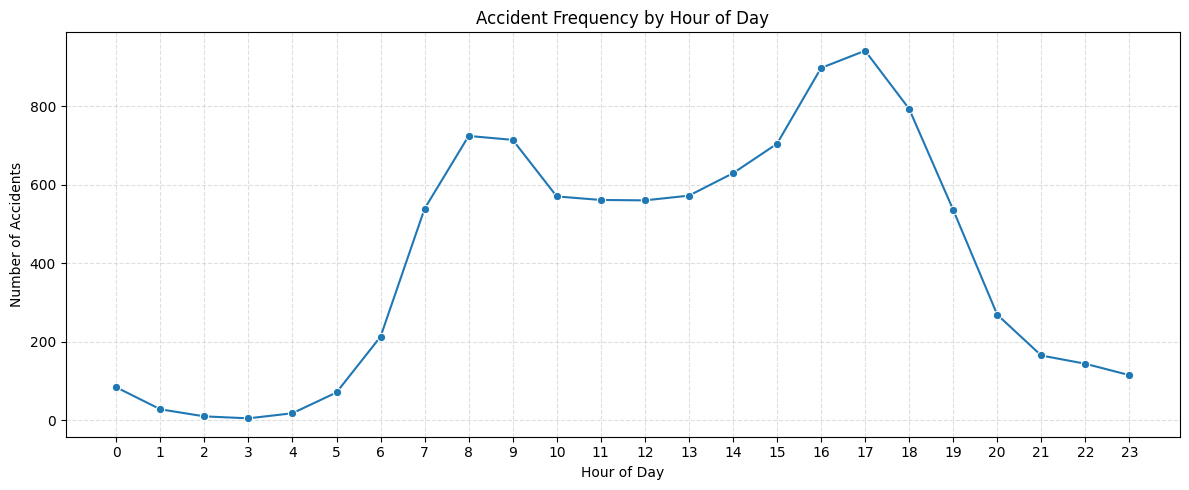

In [8]:
##keep but different presentation##
hour_counts = TPG_Accidents['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o')
plt.title('Accident Frequency by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [9]:
TPG_Accidents['Jour_dt'] = pd.to_datetime(TPG_Accidents['Jour'], errors='coerce')
TPG_Accidents['Weekday'] = TPG_Accidents['Jour_dt'].dt.day_name()

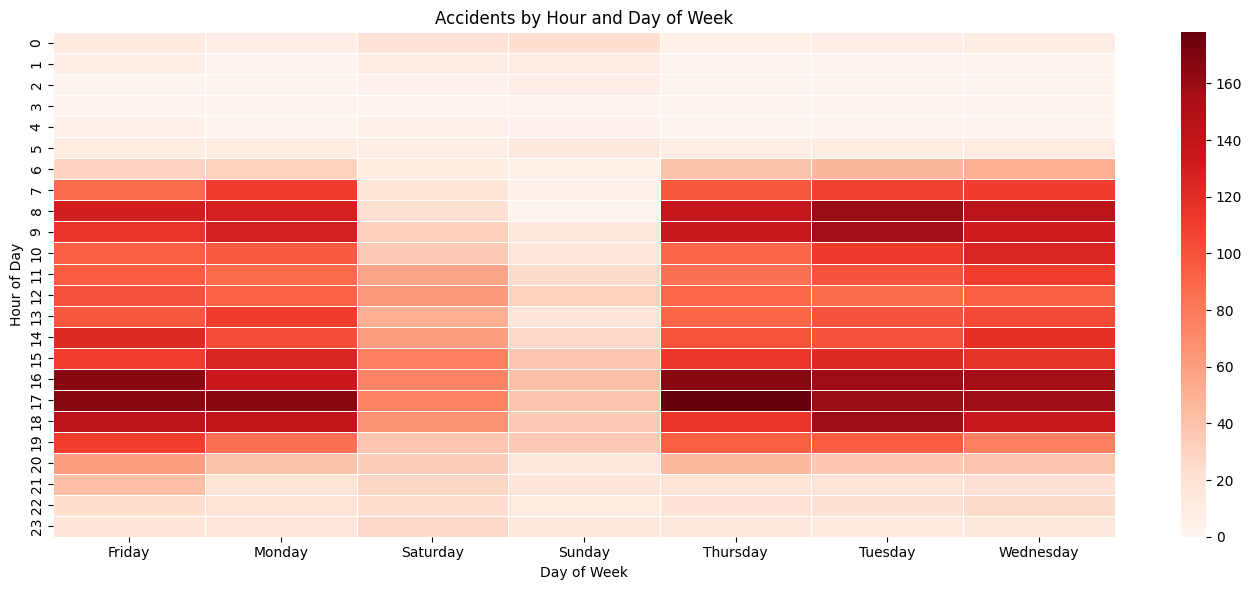

In [10]:
##boring##
weekday_hour = pd.crosstab(TPG_Accidents['Hour'], TPG_Accidents['Weekday'])

plt.figure(figsize=(14, 6))
sns.heatmap(weekday_hour, cmap='Reds', linewidths=0.5)
plt.title('Accidents by Hour and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

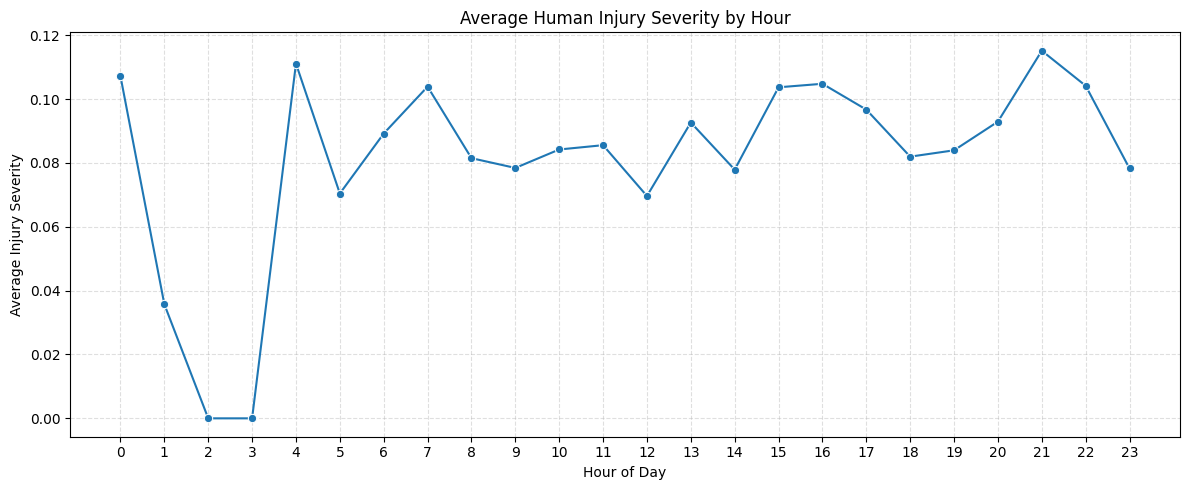

In [11]:
##boring##
injury_by_hour = TPG_Accidents.groupby('Hour')['Niv. Blessure (Humain)'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=injury_by_hour.index, y=injury_by_hour.values, marker='o')
plt.title('Average Human Injury Severity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Injury Severity')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

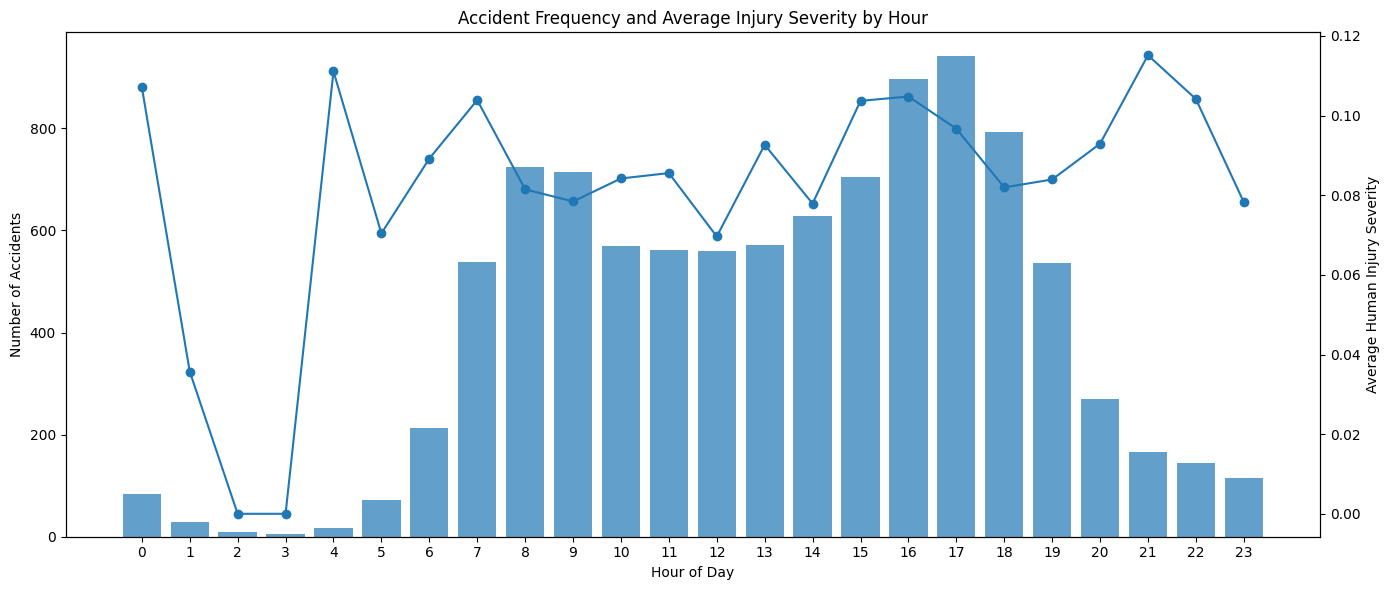

In [12]:
##boring##

hour_freq = TPG_Accidents.groupby('Hour').size()
hour_injury = TPG_Accidents.groupby('Hour')['Niv. Blessure (Humain)'].mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bars for accident counts
ax1.bar(hour_freq.index, hour_freq.values, alpha=0.7)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Accidents')
ax1.set_xticks(range(0, 24))

# Line for severity
ax2 = ax1.twinx()
ax2.plot(hour_injury.index, hour_injury.values, marker='o')
ax2.set_ylabel('Average Human Injury Severity')

plt.title('Accident Frequency and Average Injury Severity by Hour')
plt.tight_layout()
plt.show()

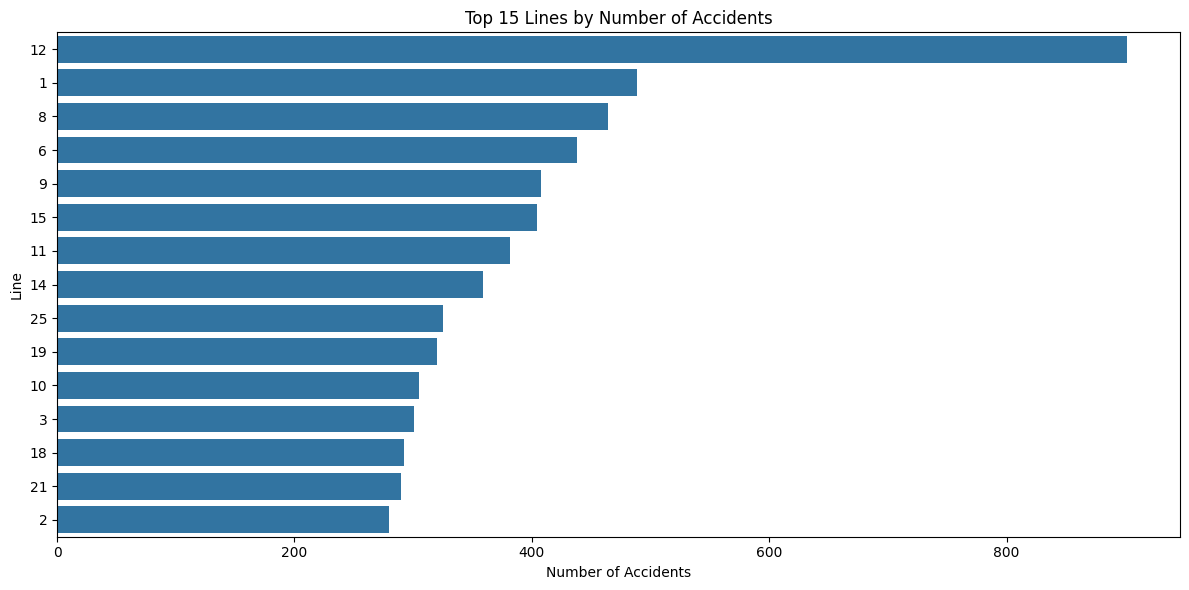

In [13]:
##keep but different presentation##
top_lines = TPG_Accidents['Ligne'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_lines.values, y=top_lines.index)
plt.title('Top 15 Lines by Number of Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Line')
plt.tight_layout()
plt.show()


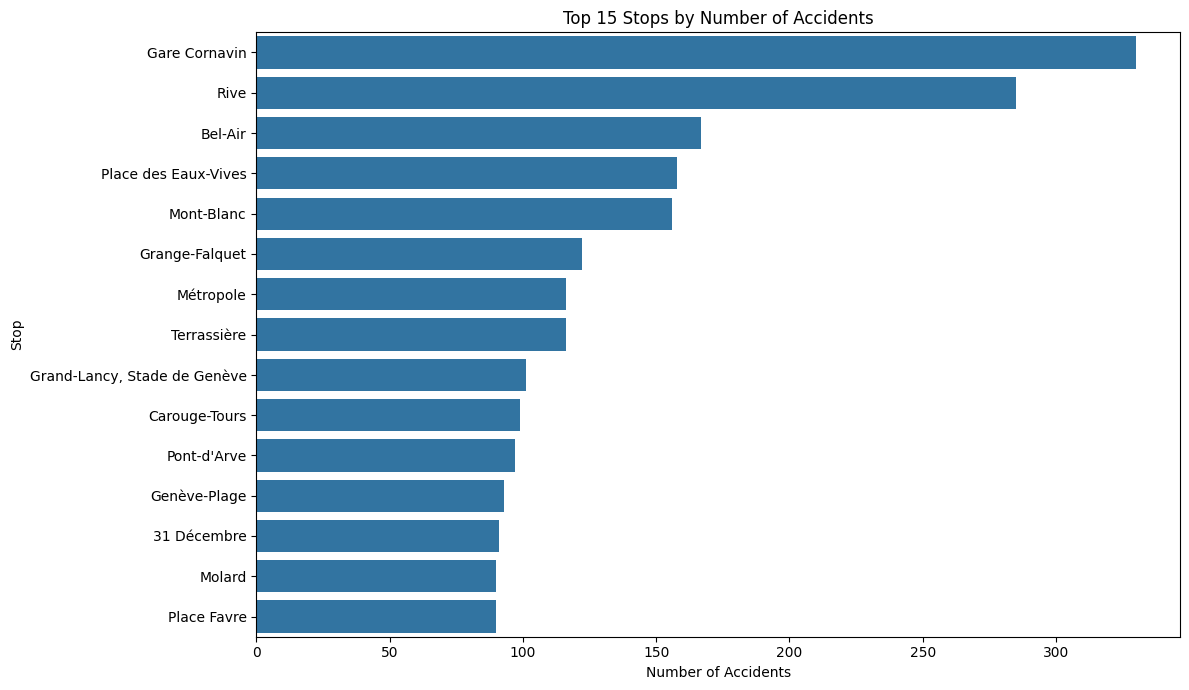

In [14]:
##keep but different presentation##
top_stops = TPG_Accidents['Arrêt'].value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_stops.values, y=top_stops.index)
plt.title('Top 15 Stops by Number of Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Stop')
plt.tight_layout()
plt.show()

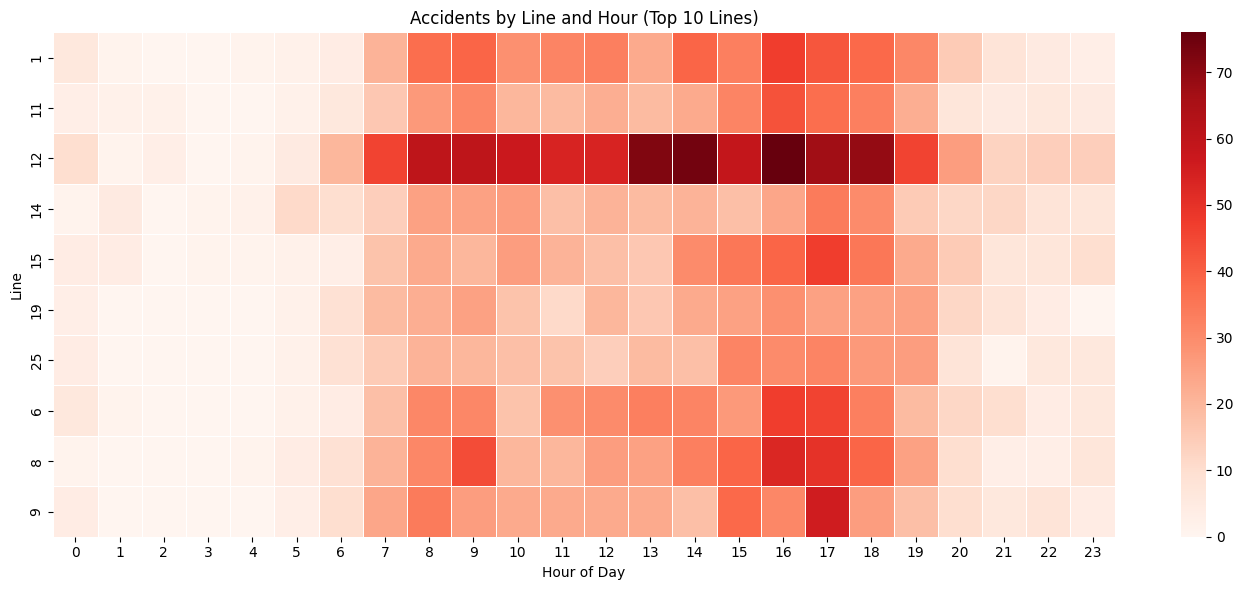

In [15]:
##boring##
top10_line_names = TPG_Accidents['Ligne'].value_counts().head(10).index
subset = TPG_Accidents[TPG_Accidents['Ligne'].isin(top10_line_names)]

line_hour = pd.crosstab(subset['Ligne'], subset['Hour'])

plt.figure(figsize=(14, 6))
sns.heatmap(line_hour, cmap='Reds', linewidths=0.5)
plt.title('Accidents by Line and Hour (Top 10 Lines)')
plt.xlabel('Hour of Day')
plt.ylabel('Line')
plt.tight_layout()
plt.show()


In [16]:
##i wanna work with those categories of morning/midday/evening/night##

TPG_Accidents = TPG_Details[
    TPG_Details['Cat'].astype(str).str.strip().str.lower() == 'accident'
].copy()

# Time parsing
TPG_Accidents['Heure_dt'] = pd.to_datetime(TPG_Accidents['Heure'], format='%H:%M:%S', errors='coerce')
TPG_Accidents['Hour'] = TPG_Accidents['Heure_dt'].dt.hour
TPG_Accidents['Minute'] = TPG_Accidents['Heure_dt'].dt.minute

# Optional: day parsing if Jour is date-like
TPG_Accidents['Jour_dt'] = pd.to_datetime(TPG_Accidents['Jour'], errors='coerce')
TPG_Accidents['Weekday'] = TPG_Accidents['Jour_dt'].dt.day_name()

# Optional: rush-hour label
def classify_period(hour):
    if pd.isna(hour):
        return 'Unknown'
    elif 6 <= hour <= 9:
        return 'Morning Rush'
    elif 10 <= hour <= 15:
        return 'Midday'
    elif 16 <= hour <= 19:
        return 'Evening Rush'
    elif 20 <= hour <= 23:
        return 'Evening'
    else:
        return 'Night'

TPG_Accidents['Time_Period'] = TPG_Accidents['Hour'].apply(classify_period)


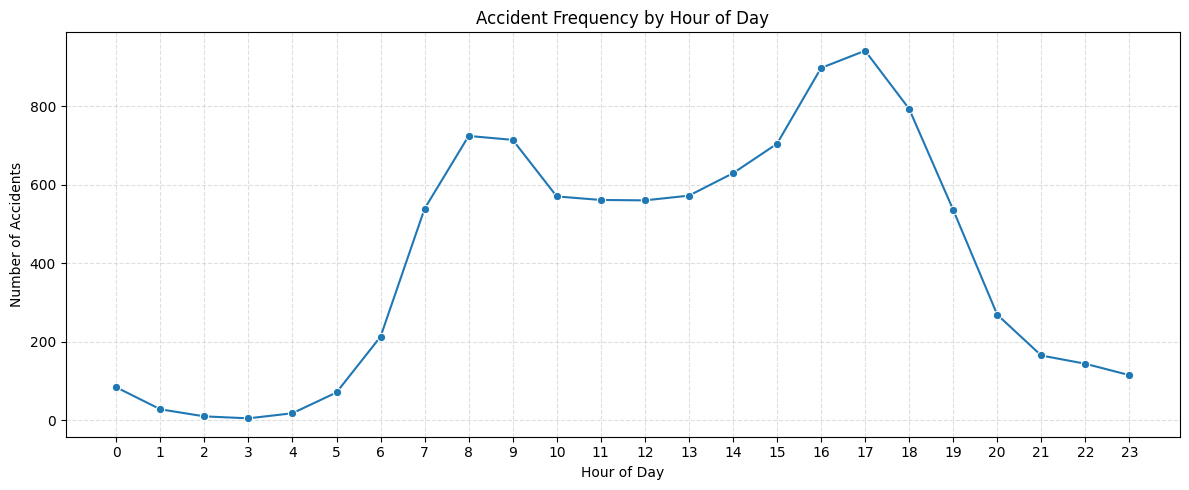

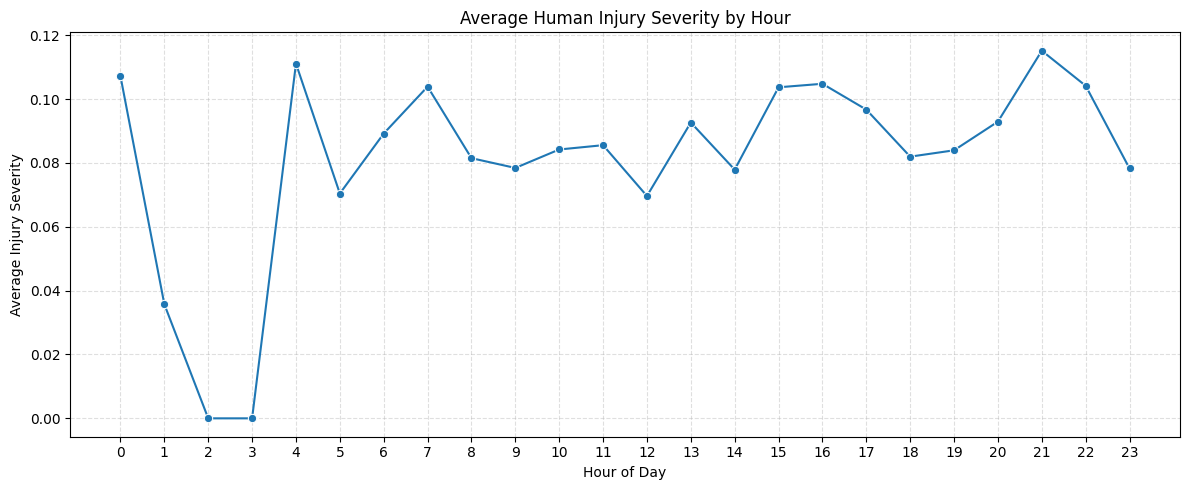

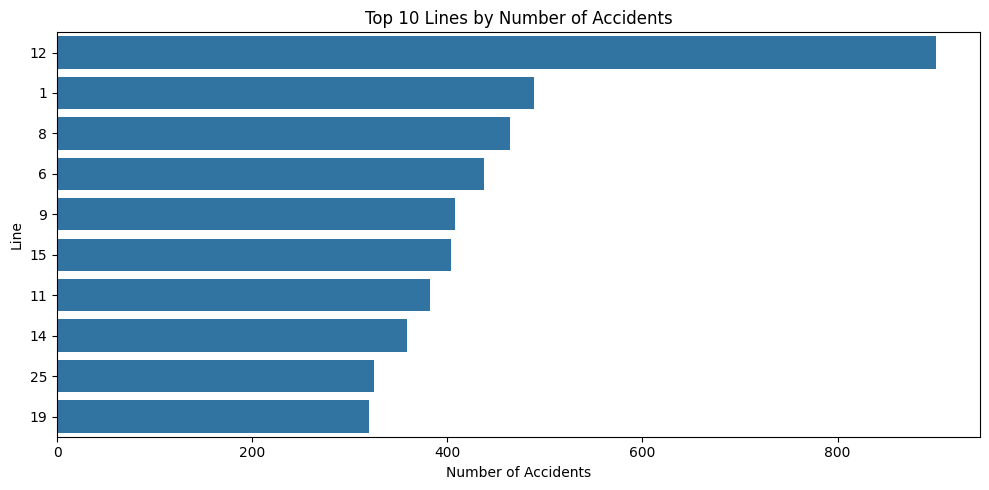

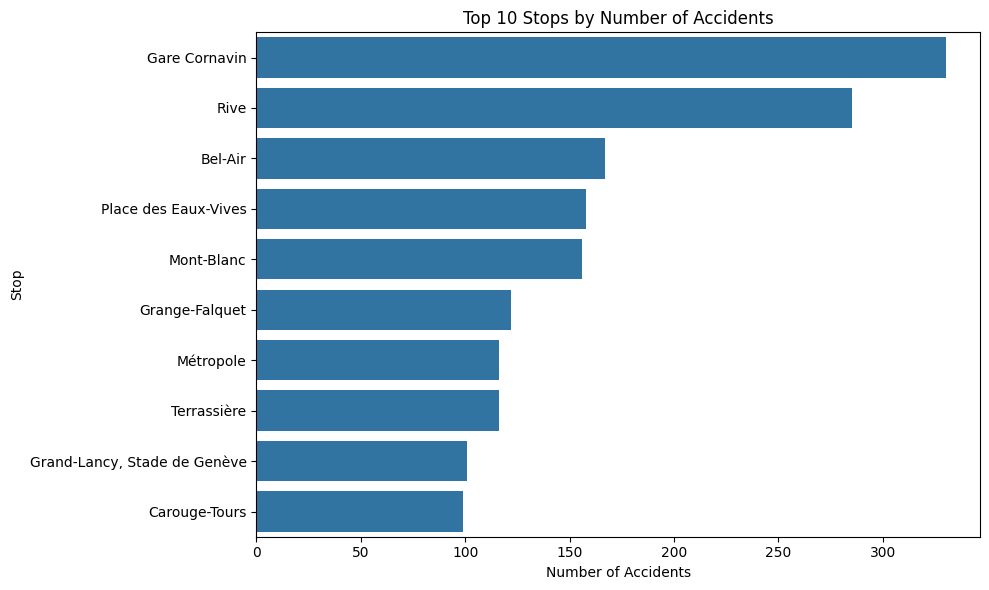

In [17]:
##those are all together##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter accidents safely
TPG_Accidents = TPG_Details[
    TPG_Details['Cat'].astype(str).str.strip().str.lower() == 'accident'
].copy()

# Convert time and extract hour
TPG_Accidents['Heure_dt'] = pd.to_datetime(TPG_Accidents['Heure'], format='%H:%M:%S', errors='coerce')
TPG_Accidents['Hour'] = TPG_Accidents['Heure_dt'].dt.hour

# 1) Accident frequency by hour
hour_counts = TPG_Accidents['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o')
plt.title('Accident Frequency by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 2) Avg injury severity by hour
injury_by_hour = TPG_Accidents.groupby('Hour')['Niv. Blessure (Humain)'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=injury_by_hour.index, y=injury_by_hour.values, marker='o')
plt.title('Average Human Injury Severity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Injury Severity')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 3) Top 10 lines
top_lines = TPG_Accidents['Ligne'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_lines.values, y=top_lines.index)
plt.title('Top 10 Lines by Number of Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Line')
plt.tight_layout()
plt.show()

# 4) Top 10 stops
top_stops = TPG_Accidents['Arrêt'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_stops.values, y=top_stops.index)
plt.title('Top 10 Stops by Number of Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Stop')
plt.tight_layout()
plt.show()


ARTICLE WORTHY PLOTS

In [18]:
# Base copy
df = df_tpg.copy()

# Parse date
df['Jour_dt'] = pd.to_datetime(df['Jour'], errors='coerce')
df['Year'] = df['Jour_dt'].dt.year
df['Month'] = df['Jour_dt'].dt.month
df['Weekday'] = df['Jour_dt'].dt.day_name()

# Parse time
df['Heure_dt'] = pd.to_datetime(df['Heure'], format='%H:%M:%S', errors='coerce')
df['Hour'] = df['Heure_dt'].dt.hour

# Restrict to 2015–2025 only
df_10y = df[(df['Year'] >= 2015) & (df['Year'] <= 2025)].copy()

# Accidents only
acc_10y = df_10y[df_10y['Cat'].astype(str).str.strip().str.lower() == 'accident'].copy()


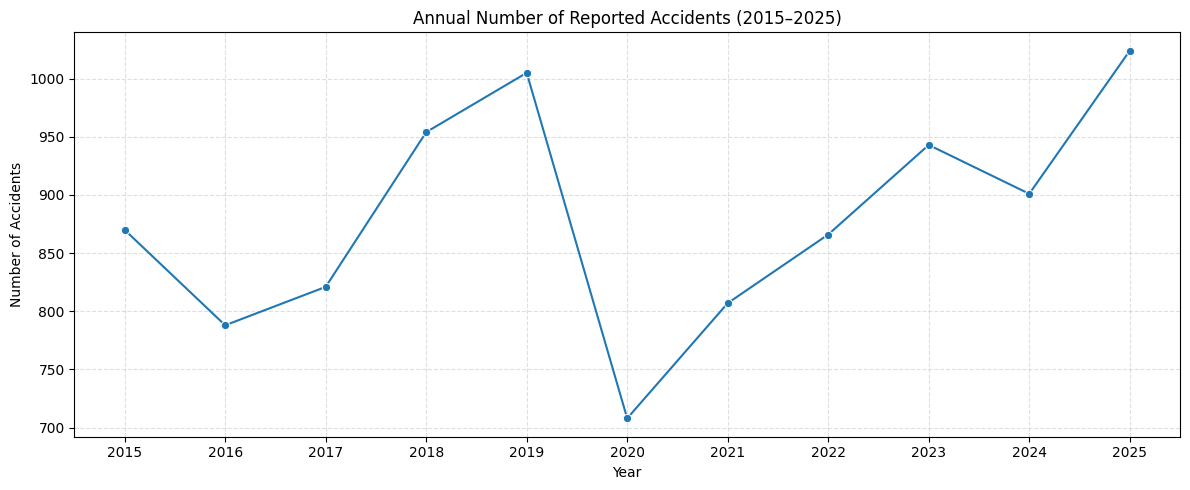

In [19]:
##boring, old version##

annual_accidents = acc_10y.groupby('Year').size()

plt.figure(figsize=(12, 5))
sns.lineplot(x=annual_accidents.index, y=annual_accidents.values, marker='o')
plt.title('Annual Number of Reported Accidents (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(range(2015, 2026))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

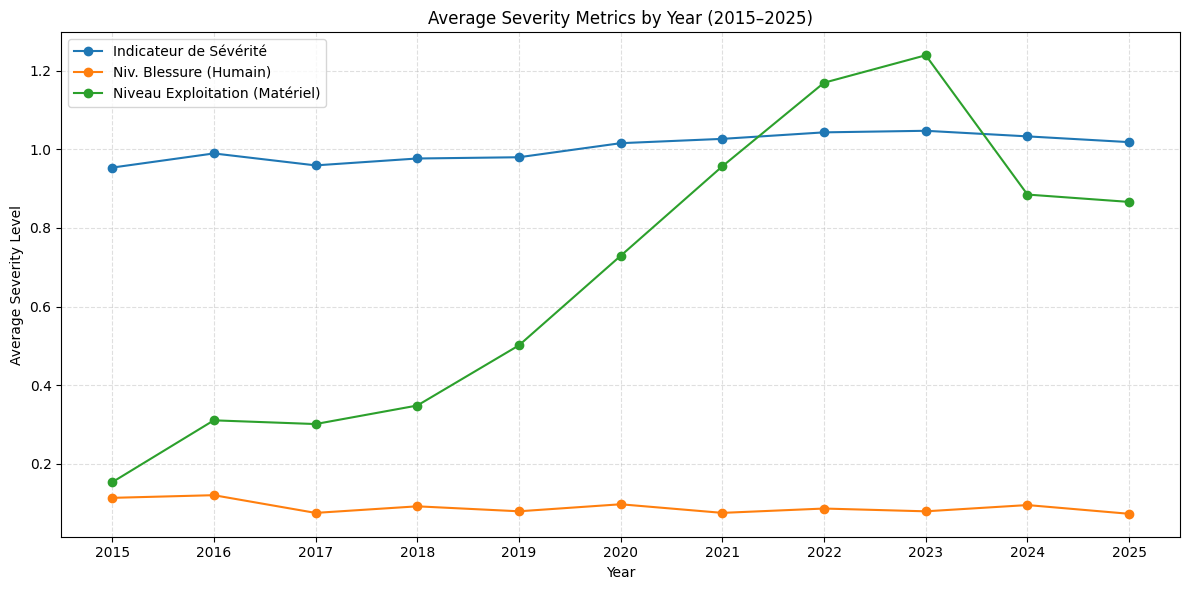

In [20]:
##boring##

severity_year = acc_10y.groupby('Year')[[
    'Indicateur de Sévérité',
    'Niv. Blessure (Humain)',
    'Niveau Exploitation (Matériel)'
]].mean()

plt.figure(figsize=(12, 6))
for col in severity_year.columns:
    plt.plot(severity_year.index, severity_year[col], marker='o', label=col)

plt.title('Average Severity Metrics by Year (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Average Severity Level')
plt.xticks(range(2015, 2026))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

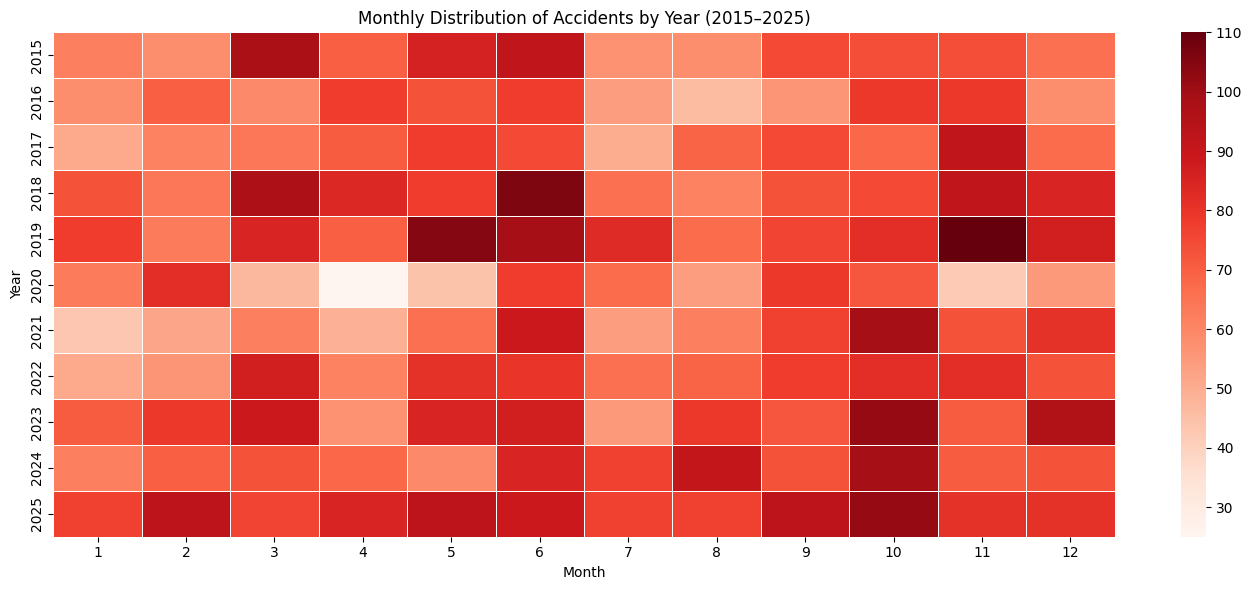

In [21]:
##boring##

monthly_year = pd.crosstab(acc_10y['Year'], acc_10y['Month'])

plt.figure(figsize=(14, 6))
sns.heatmap(monthly_year, cmap='Reds', linewidths=0.5)
plt.title('Monthly Distribution of Accidents by Year (2015–2025)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


In [22]:
acc_2025 = acc_10y[acc_10y['Year'] == 2025].copy()
acc_2024 = acc_10y[acc_10y['Year'] == 2024].copy()

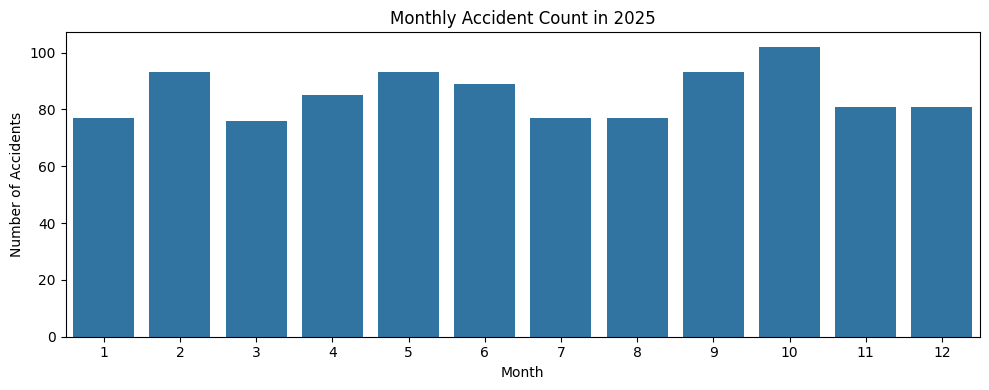

In [23]:
##boring##

acc_2025_month = acc_2025.groupby('Month').size()

plt.figure(figsize=(10, 4))
sns.barplot(x=acc_2025_month.index, y=acc_2025_month.values)
plt.title('Monthly Accident Count in 2025')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.show()


In [24]:
##boring##

line_2025 = acc_2025['Ligne'].value_counts(normalize=True)
line_10y = acc_10y['Ligne'].value_counts(normalize=True)

line_compare = pd.concat([line_2025, line_10y], axis=1)
line_compare.columns = ['Share_2025', 'Share_2015_2025']
line_compare['Difference'] = line_compare['Share_2025'] - line_compare['Share_2015_2025']

line_compare = line_compare.sort_values('Difference', ascending=False)
print(line_compare.head(10))


          Share_2025  Share_2015_2025  Difference
Ligne                                            
NotFound    0.039062         0.021843    0.017220
15          0.057617         0.040787    0.016830
60          0.019531         0.003934    0.015598
17          0.034180         0.019876    0.014304
G           0.019531         0.011905    0.007626
25          0.040039         0.032919    0.007120
50          0.012695         0.005590    0.007105
40          0.007812         0.000828    0.006984
83          0.007812         0.001035    0.006777
71          0.006836         0.000828    0.006008


In [25]:
##keep, include difference col and average in 2015-2025##

top5_2024 = acc_2024['Ligne'].value_counts().head(5)
top5_2025 = acc_2025['Ligne'].value_counts().head(5)

rank_compare = pd.concat([top5_2024, top5_2025], axis=1)
rank_compare.columns = ['2024 Count', '2025 Count']
rank_compare = rank_compare.fillna(0).astype(int)
print(rank_compare)


       2024 Count  2025 Count
Ligne                        
12             67          91
6              47          48
11             43          44
15             41          59
14             40           0
1               0          42


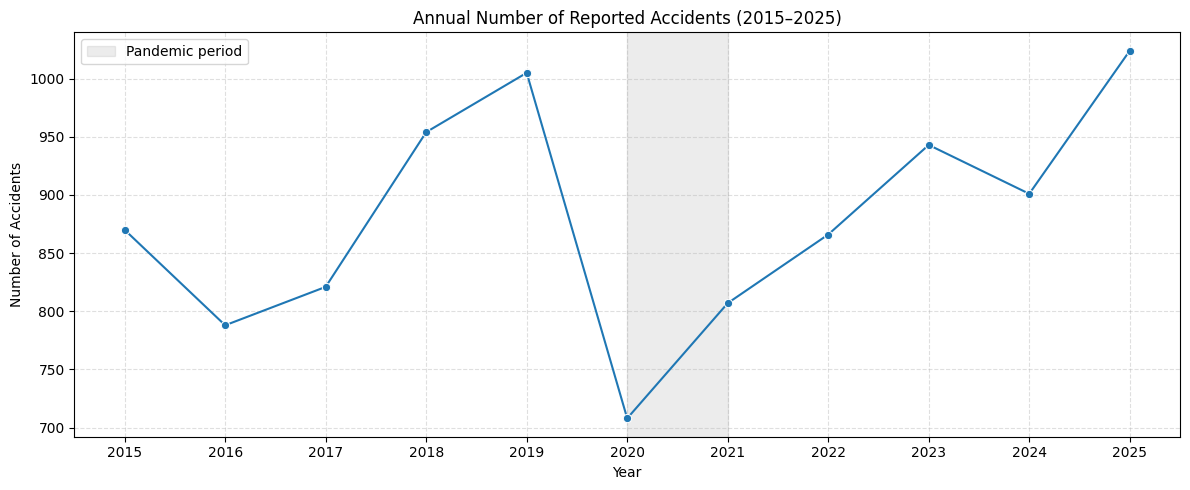

In [26]:
##interesting but needs refinement on band and needs quartiles of each year##

plt.figure(figsize=(12, 5))
sns.lineplot(x=annual_accidents.index, y=annual_accidents.values, marker='o')

plt.axvspan(2020, 2021, color='gray', alpha=0.15, label='Pandemic period')
plt.title('Annual Number of Reported Accidents (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(range(2015, 2026))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

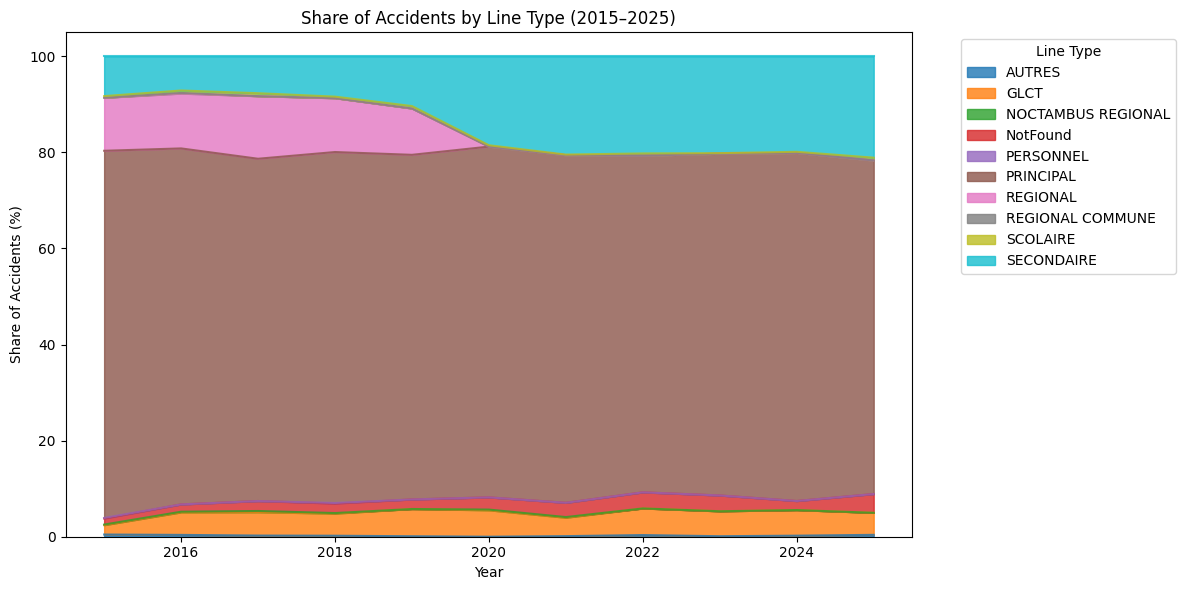

In [27]:
##boring##

mode_year = pd.crosstab(acc_10y['Year'], acc_10y['Ligne Type Hist.'], normalize='index') * 100

mode_year.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.8)
plt.title('Share of Accidents by Line Type (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Share of Accidents (%)')
plt.legend(title='Line Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [28]:
severe_2025 = acc_2025[acc_2025['Indicateur de Sévérité'] >= acc_2025['Indicateur de Sévérité'].quantile(0.9)]

/tmp/ipykernel_1979/378791458.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


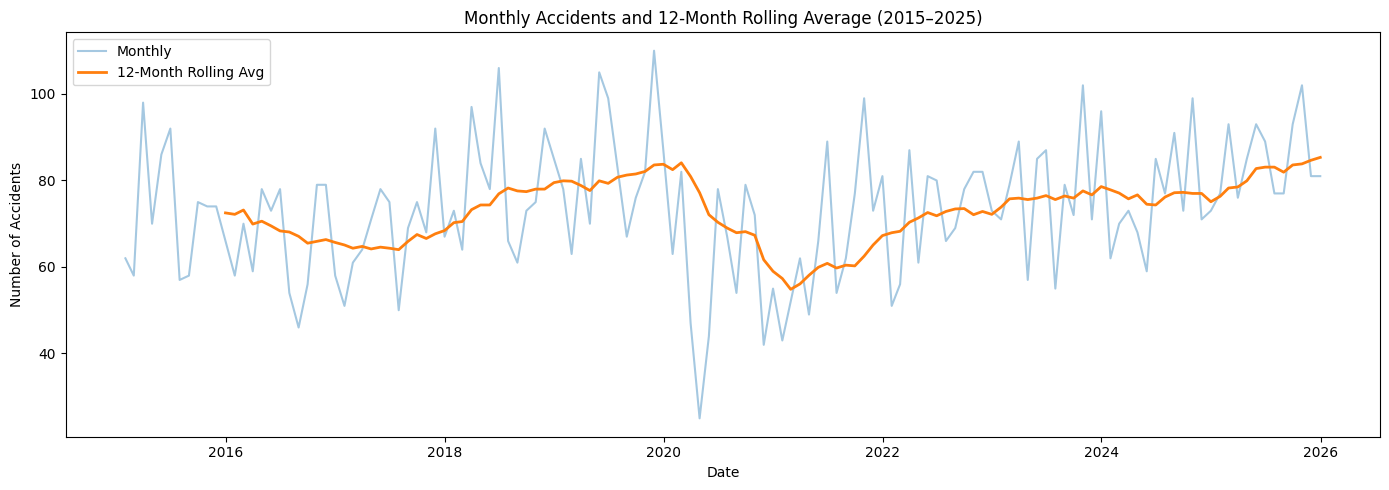

In [29]:
##interesting but improvable##

monthly_counts = (
    acc_10y
    .set_index('Jour_dt')
    .resample('M')
    .size()
)

rolling_12m = monthly_counts.rolling(12).mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_counts.index, monthly_counts.values, alpha=0.4, label='Monthly')
plt.plot(rolling_12m.index, rolling_12m.values, linewidth=2, label='12-Month Rolling Avg')
plt.title('Monthly Accidents and 12-Month Rolling Average (2015–2025)')
plt.xlabel('Date')
plt.ylabel('Number of Accidents')
plt.legend()
plt.tight_layout()
plt.show()


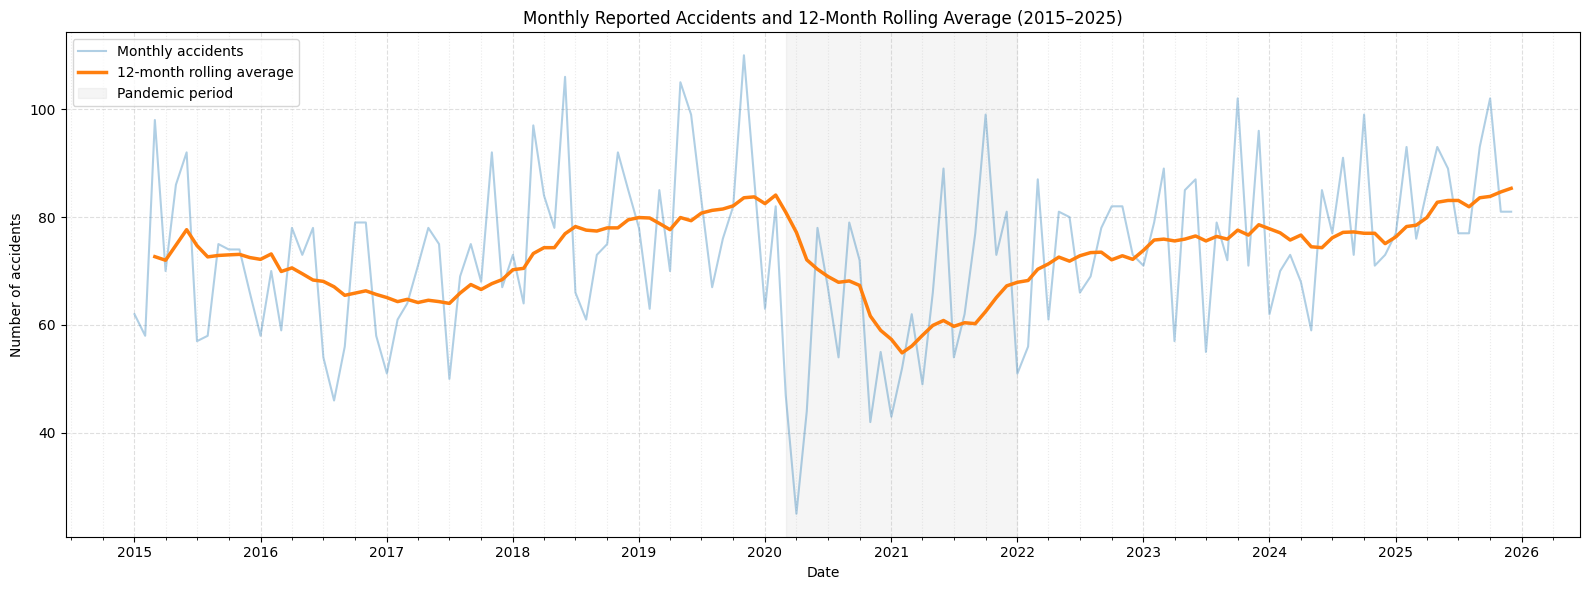

In [30]:
import matplotlib.dates as mdates

monthly_counts = (
    acc_10y
    .set_index('Jour_dt')
    .resample('MS')   # Month start
    .size()
)

rolling_12 = monthly_counts.rolling(12, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(16, 6))

# Raw monthly counts
ax.plot(monthly_counts.index, monthly_counts.values, alpha=0.35, label='Monthly accidents')

# Rolling average
ax.plot(rolling_12.index, rolling_12.values, linewidth=2.5, label='12-month rolling average')

# Major ticks: years
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Minor ticks: quarter starts
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

# Gridlines
ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', axis='x', linestyle=':', alpha=0.25)

# Optional: shade pandemic period
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'), color='gray', alpha=0.08, label='Pandemic period')

ax.set_title('Monthly Reported Accidents and 12-Month Rolling Average (2015–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of accidents')
ax.legend()
plt.tight_layout()
plt.show()


INFERENCE STATS

In [31]:
def classify_electrification(cat):
    if pd.isna(cat):
        return np.nan

    cat = str(cat).strip().lower()

    # Electric fixed-infrastructure modes
    if cat in ['tramway', 'trolleybus']:
        return 'Electric'

    # Bus-based services (treated as non-electric proxy for comparison)
    elif cat in [
        'autobus noctambus',
        'autobus principal',
        'autobus regional',
        'autobus secondaire',
        'glct',
        'scolaire'
    ]:
        return 'BusBased'

    # Exclude ambiguous / special services
    elif cat in [
        'autres',
        'manifestations',
        'notfound',
        'open days cern',
        'personnel',
        'salon auto'
    ]:
        return np.nan

    else:
        return np.nan


In [32]:
import pandas as pd
import numpy as np

# Base copy
df = df_tpg.copy()

# Parse date and time
df['Jour_dt'] = pd.to_datetime(df['Jour'], errors='coerce')
df['Year'] = df['Jour_dt'].dt.year
df['Month'] = df['Jour_dt'].dt.month
df['Heure_dt'] = pd.to_datetime(df['Heure'], format='%H:%M:%S', errors='coerce')
df['Hour'] = df['Heure_dt'].dt.hour

# Restrict to 2015–2025
df = df[(df['Year'] >= 2015) & (df['Year'] <= 2025)].copy()

# Accidents only
acc = df[df['Cat'].astype(str).str.strip().str.lower() == 'accident'].copy()

# Electrification proxy
def classify_electrification(cat):
    if pd.isna(cat):
        return np.nan

    cat = str(cat).strip().lower()

    if cat in ['tramway', 'trolleybus']:
        return 'Electric'
    elif cat in [
        'autobus noctambus',
        'autobus principal',
        'autobus regional',
        'autobus secondaire',
        'glct',
        'scolaire'
    ]:
        return 'BusBased'
    elif cat in [
        'autres',
        'manifestations',
        'notfound',
        'open days cern',
        'personnel',
        'salon auto'
    ]:
        return np.nan
    else:
        return np.nan

acc['Electrification_Group'] = acc['Ligne Catégorie Hist.'].apply(classify_electrification)

# Keep only rows usable for inference
acc_infer = acc[acc['Electrification_Group'].notna()].copy()

# 2025 subset for descriptive
acc_2025 = acc[acc['Year'] == 2025].copy()

print(acc_infer['Electrification_Group'].value_counts())
print(acc_infer['Ligne Catégorie Hist.'].value_counts(dropna=False))

Electrification_Group
BusBased    5497
Electric    3927
Name: count, dtype: int64
Ligne Catégorie Hist.
AUTOBUS PRINCIPAL     3068
TRAMWAY               2114
TROLLEYBUS            1813
AUTOBUS SECONDAIRE    1431
AUTOBUS REGIONAL       498
GLCT                   457
SCOLAIRE                36
AUTOBUS NOCTAMBUS        7
Name: count, dtype: int64


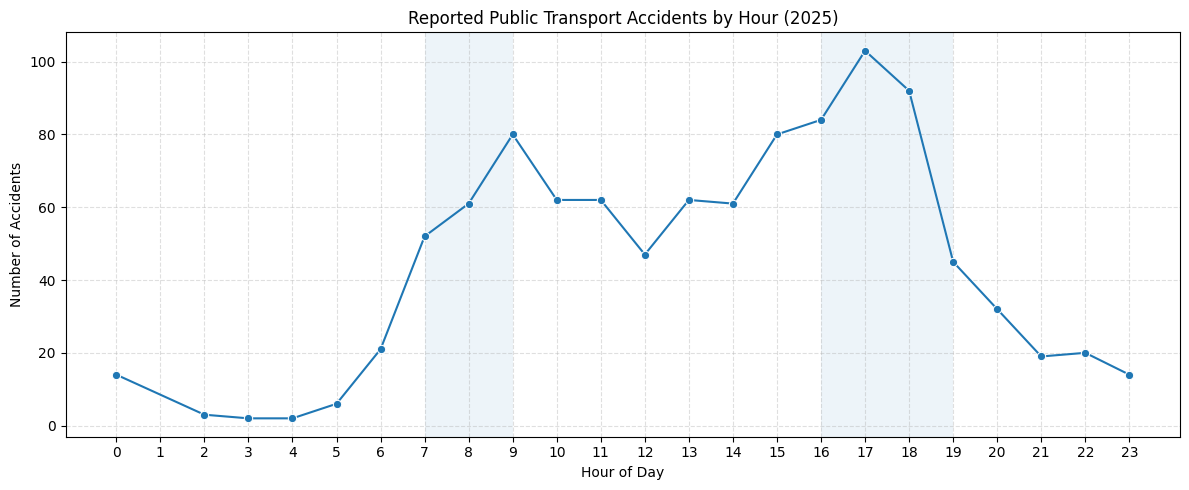

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

hour_counts = acc_2025['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o')
plt.axvspan(7, 9, alpha=0.08)
plt.axvspan(16, 19, alpha=0.08)
plt.title('Reported Public Transport Accidents by Hour (2025)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


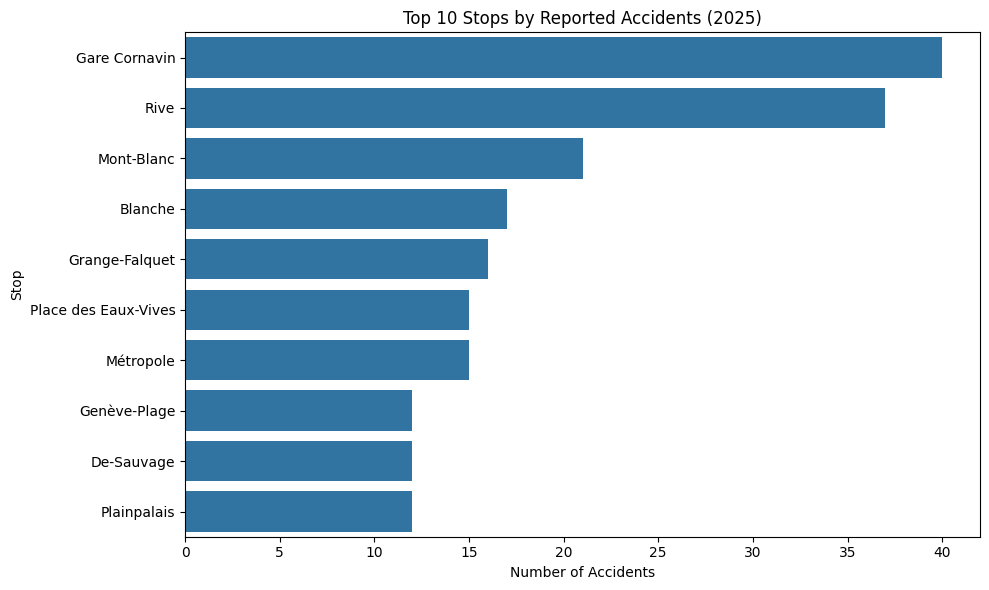

In [34]:
top_stops = acc_2025['Arrêt'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_stops.values, y=top_stops.index)
plt.title('Top 10 Stops by Reported Accidents (2025)')
plt.xlabel('Number of Accidents')
plt.ylabel('Stop')
plt.tight_layout()
plt.show()


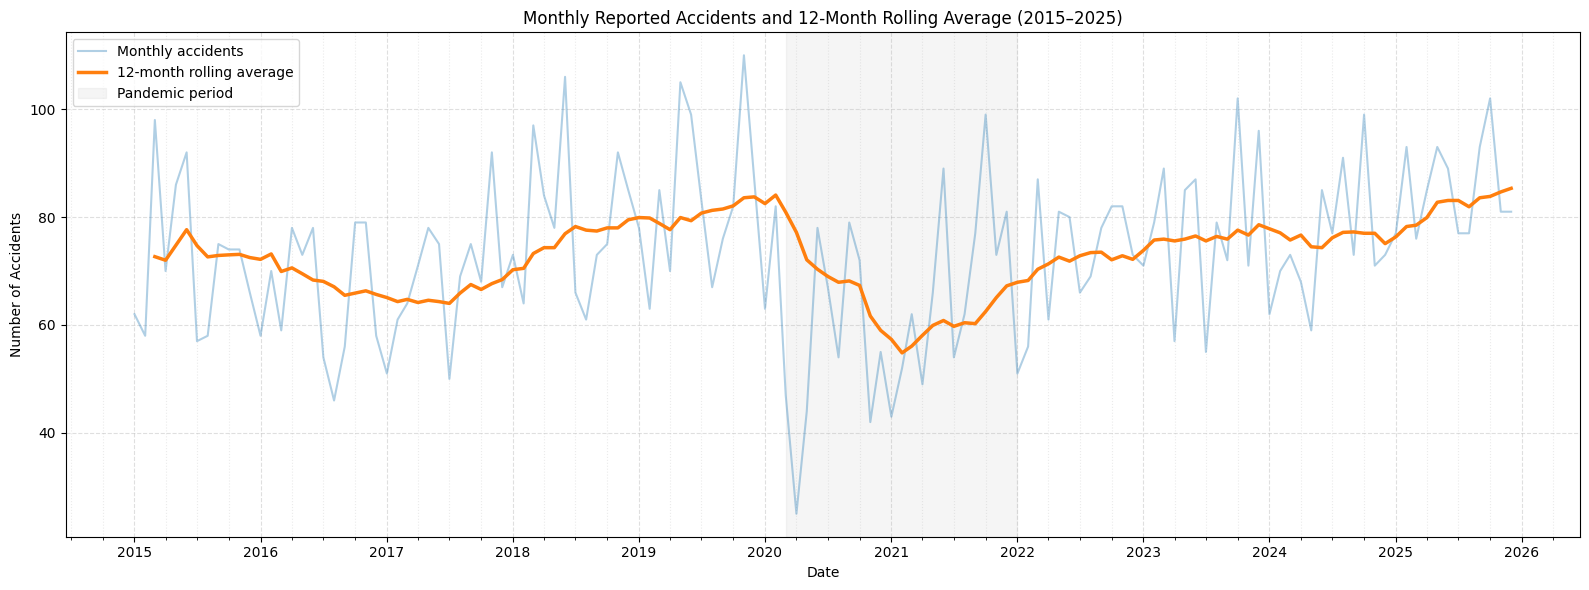

In [35]:
import matplotlib.dates as mdates

monthly_counts = (
    acc.set_index('Jour_dt')
    .resample('MS')
    .size()
)

rolling_12 = monthly_counts.rolling(12, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(16, 6))

# Monthly raw
ax.plot(monthly_counts.index, monthly_counts.values, alpha=0.35, label='Monthly accidents')

# Rolling average
ax.plot(rolling_12.index, rolling_12.values, linewidth=2.5, label='12-month rolling average')

# Major ticks = year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Minor ticks = quarter starts
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

# Grid
ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', axis='x', linestyle=':', alpha=0.25)

# Optional pandemic shading
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           color='gray', alpha=0.08, label='Pandemic period')

ax.set_title('Monthly Reported Accidents and 12-Month Rolling Average (2015–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Accidents')
ax.legend()
plt.tight_layout()
plt.show()


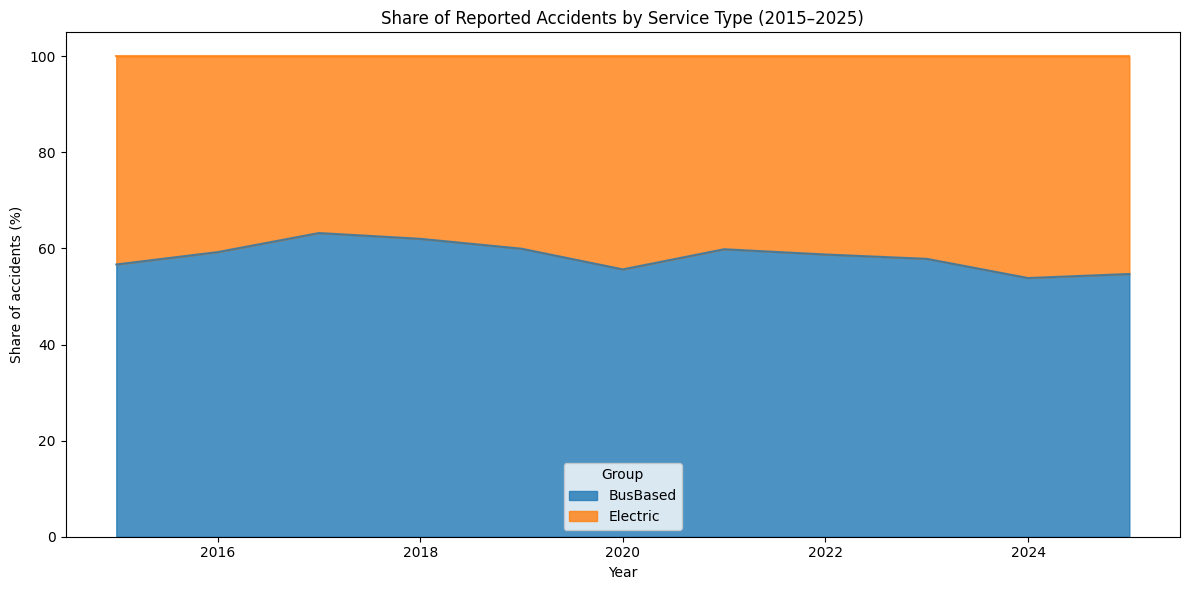

In [36]:
group_year = pd.crosstab(
    acc_infer['Year'],
    acc_infer['Electrification_Group'],
    normalize='index'
) * 100

group_year.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.8)
plt.title('Share of Reported Accidents by Service Type (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Share of accidents (%)')
plt.legend(title='Group')
plt.tight_layout()
plt.show()


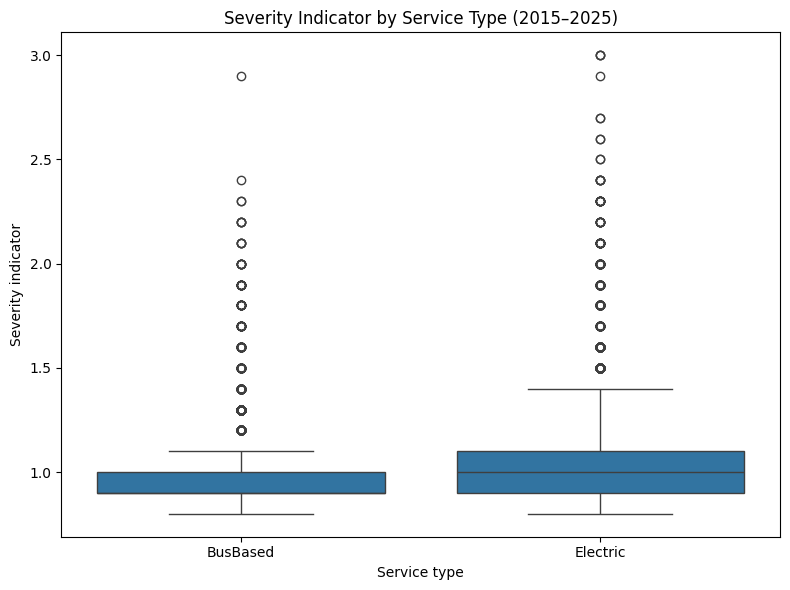

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=acc_infer, x='Electrification_Group', y='Indicateur de Sévérité')
plt.title('Severity Indicator by Service Type (2015–2025)')
plt.xlabel('Service type')
plt.ylabel('Severity indicator')
plt.tight_layout()
plt.show()


In [38]:
from scipy.stats import chi2_contingency

acc_infer['Period'] = pd.cut(
    acc_infer['Year'],
    bins=[2014, 2019, 2022, 2025],
    labels=['2015-2019', '2020-2022', '2023-2025']
)

cont_table = pd.crosstab(acc_infer['Period'], acc_infer['Electrification_Group'])

chi2, p, dof, expected = chi2_contingency(cont_table)

print("Contingency Table:")
print(cont_table)
print(f"\nChi-square = {chi2:.3f}, p-value = {p:.5f}, dof = {dof}")


# If p < 0.05:
# The distribution of reported accidents between electric fixed-infrastructure modes
# and bus-based services changed significantly across the decade’s sub-periods.

Contingency Table:
Electrification_Group  BusBased  Electric
Period                                   
2015-2019                  2617      1728
2020-2022                  1342       964
2023-2025                  1538      1235

Chi-square = 15.846, p-value = 0.00036, dof = 2


In [39]:
from scipy.stats import mannwhitneyu

electric_vals = acc_infer.loc[
    acc_infer['Electrification_Group'] == 'Electric',
    'Indicateur de Sévérité'
].dropna()

bus_vals = acc_infer.loc[
    acc_infer['Electrification_Group'] == 'BusBased',
    'Indicateur de Sévérité'
].dropna()

u_stat, p_val = mannwhitneyu(electric_vals, bus_vals, alternative='two-sided')

print(f"Mann–Whitney U = {u_stat:.3f}, p-value = {p_val:.5f}")
print(f"Electric median severity = {electric_vals.median():.3f}")
print(f"BusBased median severity = {bus_vals.median():.3f}")


Mann–Whitney U = 12686370.500, p-value = 0.00000
Electric median severity = 1.000
BusBased median severity = 0.900


In [40]:
monthly_group = (
    acc_infer
    .groupby([
        pd.Grouper(key='Jour_dt', freq='MS'),
        'Electrification_Group'
    ])
    .size()
    .reset_index(name='Accident_Count')
)

monthly_group['TimeIndex'] = range(len(monthly_group))
monthly_group['MonthNum'] = monthly_group['Jour_dt'].dt.month
monthly_group['IsElectric'] = (monthly_group['Electrification_Group'] == 'Electric').astype(int)

print(monthly_group.head())


     Jour_dt Electrification_Group  Accident_Count  TimeIndex  MonthNum  \
0 2015-01-01              BusBased              26          0         1   
1 2015-01-01              Electric              35          1         1   
2 2015-02-01              BusBased              36          2         2   
3 2015-02-01              Electric              21          3         2   
4 2015-03-01              BusBased              49          4         3   

   IsElectric  
0           0  
1           1  
2           0  
3           1  
4           0  


In [41]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

poisson_model = smf.glm(
    formula='Accident_Count ~ IsElectric + TimeIndex + C(MonthNum)',
    data=monthly_group,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         Accident_Count   No. Observations:                  264
Model:                            GLM   Df Residuals:                      250
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -921.35
Date:                Tue, 17 Mar 2026   Deviance:                       424.10
Time:                        18:46:52   Pearson chi2:                     412.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.7587
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.5185      0.04

In [42]:
import numpy as np

irr = np.exp(poisson_model.params['IsElectric'])
print(f"Incident Rate Ratio (Electric vs BusBased): {irr:.3f}")


Incident Rate Ratio (Electric vs BusBased): 0.714
